# PBNN Model Training

In [1]:
import sys
import os
import csv
sys.path.append("..")

import neurobayes as nb

import numpy as np
from sklearn.preprocessing import StandardScaler    
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder

import seaborn as sns

myrcparams = {
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.autolayout': True,
}
plt.rcParams.update(myrcparams)

import pandas as pd

## Preprocessing

In [2]:
n4_df = pd.read_excel("../../data/boron_coord_final.xlsx")
n4_df = n4_df.dropna(subset='%')


In [3]:
other = ['Cr2O3', 'HfO2', 'PbO', 'UO3', 'Y2O3', 'ZrO2','Fe2O3',
         'P2O5', 'TiO2', 'CoO','SrO','Cs2O','Bi2O3','BaO','SO3','La2O3']
oxEl = ['Al2O3','B2O3','CaO','K2O','Li2O','MgO','Na2O','SiO2',
 'ZnO','Rb2O']

n4_df['other'] = n4_df[other].sum(axis=1)
class_cols = oxEl + ['other']

X = n4_df[ class_cols ].fillna(0)
y = n4_df['%']


In [4]:
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train_df.to_numpy()
X_test = X_test_df.to_numpy()
y_train = y_train_df.to_numpy()
y_test = y_test_df.to_numpy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train) 
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1))

X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test.reshape(-1,1))


## KFold Cross Validation


In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [6]:
filename = 'pbnnr_architecture_tuning.csv'

if not os.path.exists(f'./{filename}'):
    with open(filename, 'w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames = ['arch', 'r2', 'rmse'])
        writer.writeheader()

    archs = [ [8, 8, 8], [16, 16, 16 ], [8,8,8,8], [16, 16, 16, 16], [32, 32, 32] ]
    for arch in archs: 
        r2 = []
        rmse = []
        y_kscaler = StandardScaler()
        X_kscaler =StandardScaler()
        for fold_idx, (train_index, test_index) in enumerate(kf.split(X_train, y_train)):
            X_ktrain = X_train[train_index]
            X_ktest = X_train[test_index]
            X_kscaler.fit(X_ktrain.reshape(-1,1))
            X_ktrain_scaled = X_kscaler.transform(X_ktrain.reshape(-1, 1)).reshape( X_ktrain.shape)
            X_ktest_scaled = X_kscaler.transform(X_ktest.reshape(-1, 1)).reshape( X_ktest.shape)

            y_ktrain = y_train[train_index]
            y_ktest = y_train[test_index]
            y_kscaler.fit(y_ktrain.reshape(-1,1))
            y_ktrain_scaled = y_kscaler.transform(y_ktrain.reshape(-1, 1)).reshape( y_ktrain.shape)
            y_ktest_scaled = y_kscaler.transform(y_ktest.reshape(-1, 1)).reshape( y_ktest.shape)

            architecture = nb.FlaxMLP(arch, target_dim=1)
            pbnn = nb.PartialBNN(architecture, probabilistic_layer_names=['Dense0', f'Dense{len(arch)}'])
            pbnn.fit(X_ktrain_scaled, y_ktrain_scaled, num_samples=1000, num_warmup=1000, sgd_epochs=1000)
            y_pred_scaled, var_pred = pbnn.predict(X_ktest_scaled)
            y_pred = y_kscaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)
            y_pred = np.maximum(y_pred, 0)
            
            r2_k = r2_score(y_ktest, y_pred)
            rmse_k = root_mean_squared_error(y_ktest, y_pred)

            r2.append(r2_k)
            rmse.append(rmse_k)

            dict = {'arch': arch,
            'r2': r2_k,
            'rmse': rmse_k}

            with open(filename, 'a', newline='') as file:
                writer = csv.DictWriter(file, fieldnames = dict.keys())
                writer.writerow(dict)

        dict = {'arch': f'{arch}_average',
                'r2': sum(r2)/len(r2),
                'rmse': sum(rmse)/len(rmse)}
        
        with open(filename, 'a', newline='') as file:
            writer = csv.DictWriter(file, fieldnames = dict.keys())
            writer.writerow(dict)

## Select best architecture

In [7]:
# Define the filename for architecture tuning results
filename = 'pbnnr_architecture_tuning.csv'

print("\nSELECTING BEST ARCHITECTURE FROM TUNING RESULTS:")

try:
    # Step 1: Read the CSV file
    df = pd.read_csv(filename)

    # Step 2: Filter rows where architectures are NOT averages (you can include averages or exclude them)
    df_filtered = df[df["arch"].astype(str).str.contains('average')]
    
    # Step 3: Define the performance metric for selecting the best architecture
    best_row = df_filtered.loc[df_filtered['r2'].idxmax()]  # Choose row with the highest accuracy
    # Alternatively, minimize RMSE:
    # best_row = df_filtered.loc[df_filtered['rmse'].idxmin()] 
    
    # Save best architecture for the model
    best_architecture = best_row['arch'].replace('_average','')  # Extract the architecture
    
    # Extract performance metrics
    best_r2 = best_row['r2']
    best_rmse = best_row['rmse']
    
    # Print the best architecture and performance metrics
    print("Best Architecture:")
    print(f"  Architecture: {best_architecture}")
    print("Performance:")
    print(f"  R²: {best_r2}")
    print(f"  RMSE: {best_rmse}")

except Exception as e:
    # Handle errors gracefully
    print(f"Error processing architecture tuning results: {str(e)}")


SELECTING BEST ARCHITECTURE FROM TUNING RESULTS:
Best Architecture:
  Architecture: [16, 16, 16]
Performance:
  R²: 0.8610065763207823
  RMSE: 7.927849200203096


## Train Final Model

In [8]:

architecture = nb.FlaxMLP(hidden_dims=best_architecture, target_dim=1)

architecture = nb.FlaxMLP(eval(best_architecture), target_dim=1)  # Convert string representation to Python list
pbnn = nb.PartialBNN(
    architecture,
    probabilistic_layer_names=['Dense0', f'Dense{len(eval(best_architecture))}'],  # Handle layers dynamically
)

pbnn.fit(X_train_scaled, y_train_scaled, num_warmup=1000, num_samples=1000)


Training deterministic NN...


Training Progress: 100%|██████████| 500/500 [00:01<00:00, 336.85it/s, Epoch 500/500, LR: 0.010000, Loss: 0.1189 ]


Training partially Bayesian NN


sample: 100%|██████████| 2000/2000 [02:17<00:00, 14.51it/s, 511 steps of size 9.45e-03. acc. prob=0.94] 


## Evaluate Test Data

In [9]:
probs_pred, var_pred = pbnn.predict(X_test_scaled)

rmse = root_mean_squared_error(y_true=y_test_scaled, y_pred=probs_pred)

r2 = r2_score(y_test_scaled, probs_pred)


print(rmse)
print(r2)

0.33415631436101273
0.8880264742350493


In [10]:
train_prob, train_var = pbnn.predict(X_train_scaled)

train_rmse = root_mean_squared_error(y_train_scaled, train_prob)
train_r2 = r2_score(y_train_scaled, train_prob)

print(train_rmse)
print(train_r2)

0.2786045776656967
0.9223794893037187


## Save model and model results

In [12]:
#Save results of models

std_var = y_scaler.scale_
# Training predictions
train_preds_scaled, train_var = pbnn.predict(X_train_scaled)
train_preds = y_scaler.inverse_transform(train_preds_scaled.reshape(-1, 1)).reshape(train_preds_scaled.shape)
train_preds = np.maximum(train_preds, 0)
train_var = train_var * std_var
train_df = pd.DataFrame({
    'y_true': y_train,
    'y_pred': train_preds.flatten(),
    'var_pred': train_var.flatten(),
    'is_train': 1
}, index=y_train_df.index)

# Test predictions
# test_preds_scaled, var_pred = model.predict(X_test.to_numpy())
test_preds =y_scaler.inverse_transform(probs_pred.reshape(-1, 1)).reshape(probs_pred.shape)
test_preds = np.maximum(test_preds, 0)
test_var = var_pred * std_var
test_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': test_preds.flatten(),
    'var_pred': test_var.flatten(),
    'is_train': 0
}, index=y_test_df.index)

# Combine train and test results
model_results = pd.concat([train_df, test_df])

# Join with glass ID
full_results = n4_df['Glass Name'].to_frame().join(model_results, how='left')

# # Save results to CSV files
full_results.to_csv(f"../results/regression/PBNN_with_cr_results.csv")

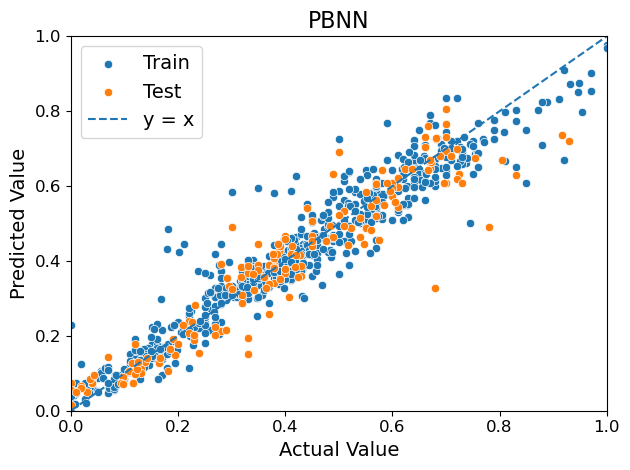

In [13]:
sns.scatterplot(x=y_train/100, y=y_scaler.inverse_transform(train_prob).ravel()/100, label='Train')
sns.scatterplot(x=y_test/100, y=y_scaler.inverse_transform(probs_pred).ravel()/100, label='Test')

# Add x = y line for reference
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', label='y = x')

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title('PBNN')
plt.legend()
plt.ylim((0,1))
plt.xlim((0,1))

plt.show()

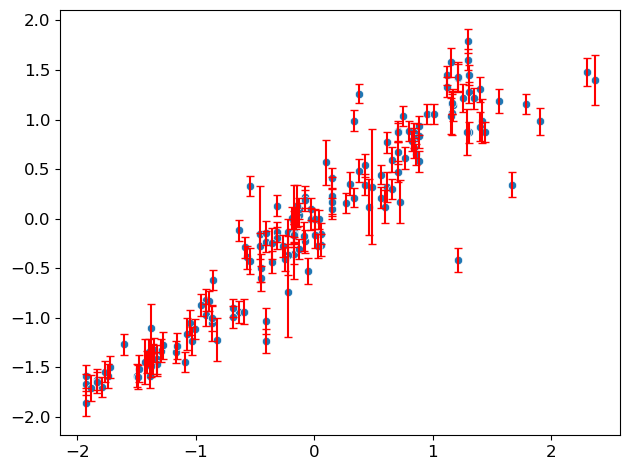

In [14]:
sns.scatterplot(x=y_test_scaled.flatten(), y=probs_pred.flatten())
plt.errorbar(yerr=var_pred.flatten(), x=y_test_scaled.flatten(), y=probs_pred.flatten(),  fmt='none', ecolor='red', capsize=3)

plt.show()

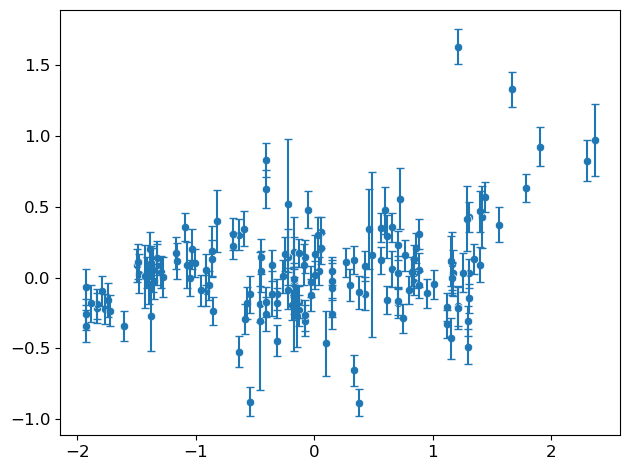

In [15]:
sns.scatterplot(x=y_test_scaled.flatten(), y=y_test_scaled.flatten()-probs_pred.flatten())
plt.errorbar(yerr=var_pred.flatten(), x=y_test_scaled.flatten(), y=y_test_scaled.flatten()-probs_pred.flatten(),  fmt='none', capsize=3)

plt.show()